#### Labels transfer of cell states from gut healthy adult single-cell RNA sequencing cells to Xenium add-on panel data with `scANVI`
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 31th July 2024
- **Last modified date:** 31th July 2024

##### Import packages

In [1]:
import scvi
import torch
import anndata as ad
import warnings
import numpy as np
import scanpy as sc
import pandas as pd
import plotnine as p
import matplotlib.pyplot as plt
import scipy.sparse

import json
from datetime import datetime

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

In [3]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

### Read in data

In [4]:
adata_ref = sc.read_h5ad('data/gut_data/Healthy_colon_adult.h5ad')

In [5]:
X_is_raw(adata_ref)

True

In [7]:
adata_xenium = sc.read_h5ad('data/gut_data/gut_hs_XeniumAdultColonNicheCompass_AM_21102024_150114_raw.h5ad')

In [8]:
X_is_raw(adata_xenium)

True

### Prepare reference dataset

+ Save raw counts

In [9]:
adata_ref.raw = adata_ref

In [10]:
adata_xenium.raw = adata_xenium

+ prepare xenium data

In [11]:
adata_xenium.obs['seed_labels'] = 'Unknown'

In [12]:
adata_xenium.obs['Donor_ID'] = 'Xenium_donor_1'

In [13]:
adata_xenium.obs['Library_Preparation_Protocol'] = 'Xenium'

In [14]:
adata_xenium.obs['Study_name'] = '10X_Xenium_gut_data'

+ Concatenate datasets

In [15]:
adata = adata_ref.concatenate(adata_xenium, batch_key = 'dataset', batch_categories = ['reference', 'query'], join='inner', index_unique = None)

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_20650/3396050185.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_ref.concatenate(adata_xenium, batch_key = 'dataset', batch_categories = ['reference', 'query'], join='inner', index_unique = None)


#### Run scVI

In [16]:
adata.layers['counts'] = adata.X.copy()

In [17]:
scvi.model.SCVI.setup_anndata(adata, 
                              categorical_covariate_keys=['Donor_ID', 
                                                          'Library_Preparation_Protocol', 
                                                          'Study_name'],
                              labels_key = "seed_labels", 
                              layer = 'counts')

In [18]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 50, 
                            n_layers = 3, 
                            dispersion = 'gene-batch', 
                            gene_likelihood = 'nb')

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvi/model/_scvi.py:159: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(


In [20]:
scvi_model.train(200, 
                 check_val_every_n_epoch = 1, 
                 enable_progress_bar = True)

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator=='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/

Epoch 200/200: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [1:31:59<00:00, 29.34s/it, v_num=1, train_loss_step=101, train_loss_epoch=107]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [1:31:59<00:00, 27.60s/it, v_num=1, train_loss_step=101, train_loss_epoch=107]


In [21]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

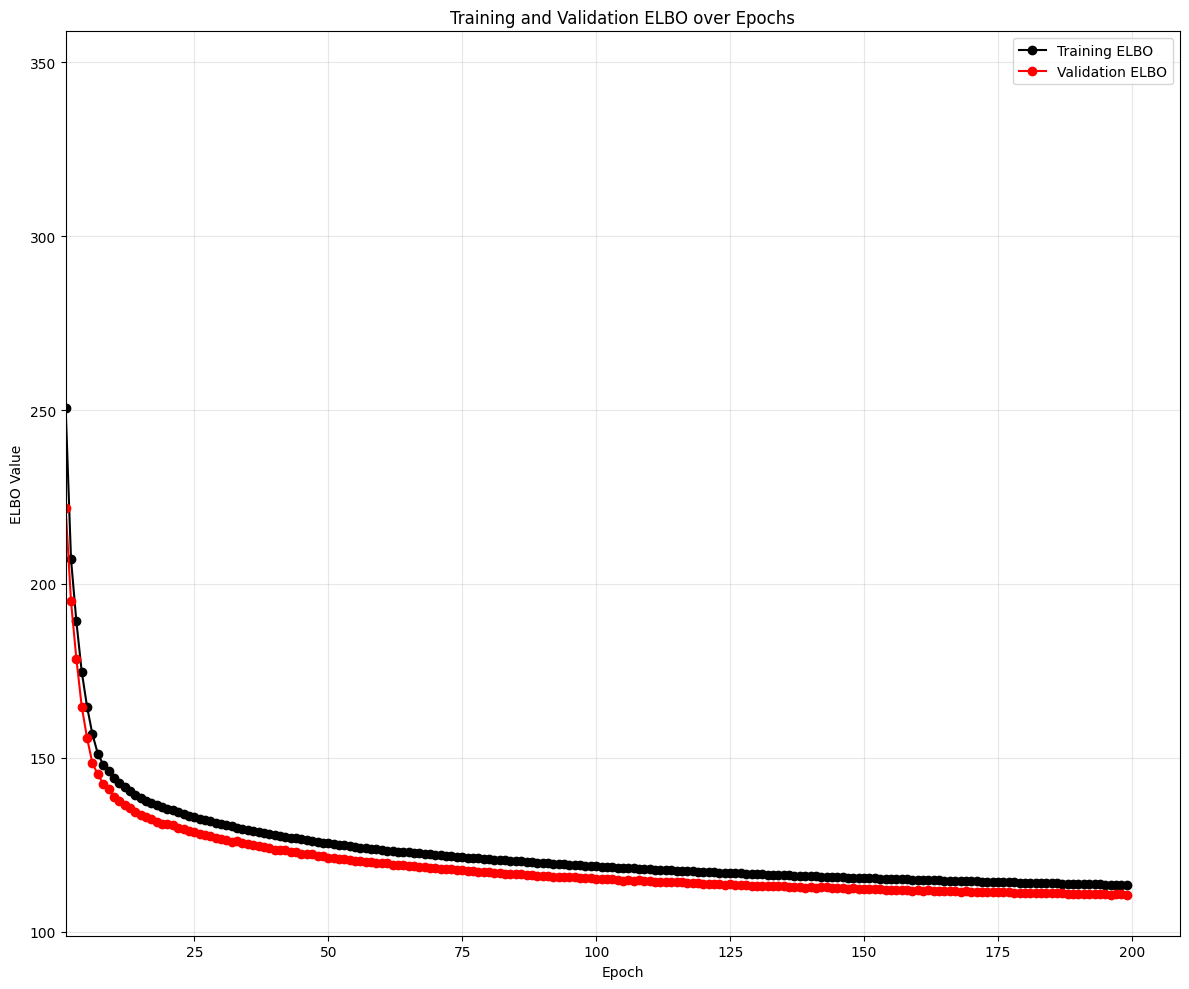

In [28]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#### Label transfer with `scANVI` 

In [29]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_model, 'Unknown')

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvi/model/_scanvi.py:139: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`


In [30]:
scanvi_model.train(200, 
                   check_val_every_n_epoch = 1, 
                   enable_progress_bar = True)

INFO     Training for 200 epochs.                                                                                  


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator=='mps' in train function.In future releases it will become default for mps supported machines.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:177: PossibleUserWarning: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data

Epoch 200/200: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [8:10:43<00:00, 200.36s/it, v_num=1, train_loss_step=121, train_loss_epoch=115]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [8:10:43<00:00, 147.22s/it, v_num=1, train_loss_step=121, train_loss_epoch=115]


In [31]:
adata.obs["C_scANVI"] = scanvi_model.predict(adata)

- Extract latent representation

In [32]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)

### Explore model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

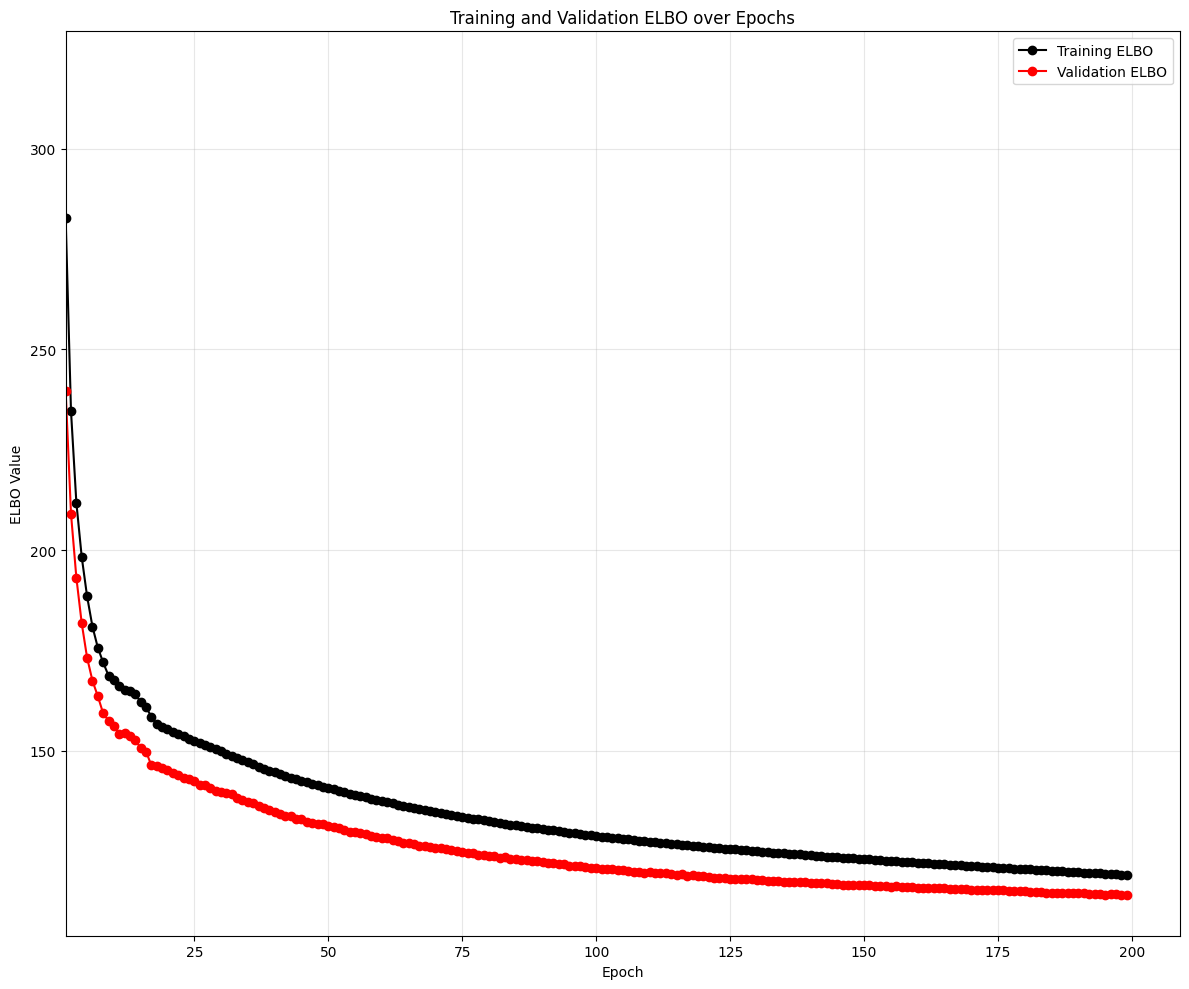

In [34]:
history_df = (
    scanvi_model.history['elbo_train'].astype(float)
    .join(scanvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars = ['epoch'])
)
     
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

In [35]:
posterior_probs = scanvi_model.predict(adata, soft=True)

In [36]:
confidence_scores = posterior_probs.max(axis=1)

In [37]:
adata.obs['confidence_score'] = confidence_scores

+ Visualize dataset

In [38]:
sc.pp.neighbors(adata, use_rep = "X_scANVI", n_neighbors = 50, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.2, spread = 2, random_state = 1712)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.


In [39]:
adata.obs['C_scANVI'].value_counts()

C_scANVI
Plasma cells          56622
TA                    56254
Fibroblasts           44754
Myofibroblasts        41525
Enterocyte            40847
Colonocyte            40558
Stem cells            24353
CD4 T                 23463
Goblet cells          23211
Macrophages           21658
B cells               17715
Pericytes              9423
BEST4+ epithelial      9313
CD8 T                  9150
Glial cells            8672
Endothelial cells      7701
DC                     7288
Mast cells             5734
Tuft cells             4117
EECs                   4045
Mature venous EC       4028
Microfold cell         3960
arterial capillary     3641
LEC                    2904
Mature arterial EC     2584
gdT                    2564
Tregs                  2248
NK                     1857
Monocytes               936
ILCs                    666
Name: count, dtype: int64

In [ ]:
fig = plt.figure(figsize=(10, 7), dpi=300)

sc.pl.umap(adata, color = ['Study_name', 'seed_labels', 'Library_Preparation_Protocol', 'C_scANVI', 'confidence_score', 'Donor_ID'], ncols = 2, frameon = False, size = 1)
plt.tight_layout()

plt.savefig('figures/scvi_scanvi_integration_umap.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'xenium_and_reference'

adata.write_h5ad(f"data/gut_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")